In [1]:
# enables automatic library refreshes when importing changes to a library
%load_ext autoreload
%autoreload 2

/work/nvme/bhvr/cadence/Stars_VAE


In [3]:
import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import profile_features, split_feature, num_profile_points, processed_data_path, raw_data_path
from src.preprocessing import rdp_preprocess, fit_preprocess_scalers


In [4]:

# loads raw data into a dataframe to be processed

sim = np.load(raw_data_path, allow_pickle=True)

df = pd.DataFrame(sim)

In [ ]:
'''Skip this step if data is already RDP processed'''
# runs RDP algorithm on raw data and saves it in data/processed
processed_df = rdp_preprocess(df, num_profile_points)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, processed_df)

# used to visualize which points were selected by rdp algorithm
from src.utils import varify_rdp

varify_rdp(df, processed_df)

In [5]:
# Reconstruct DataFrame from the RDP NumPy array output
processed_df = np.load(processed_data_path, allow_pickle=True)

column_headers = profile_features + [split_feature]
processed_dataframe = pd.DataFrame(processed_df, columns=column_headers)

# Normalize data
df_scaled, scalers = fit_preprocess_scalers(
    processed_dataframe,
    normalize=True,
    standardize=False,
)

arr = df_scaled.to_numpy()

In [6]:
from src.train import train_model
import src.config

metrics = train_model(arr)

Training on device: cuda
Model: VAE(
  (encoder): Sequential(
    (0): Linear(in_features=180, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): Leaky

(<Figure size 1500x500 with 2 Axes>,
 (<Axes: title={'center': 'Reconstruction Loss (MSE)'}, xlabel='Epoch', ylabel='MSE'>,
  <Axes: title={'center': 'Latent Divergence (KLD)'}, xlabel='Epoch', ylabel='KLD'>))

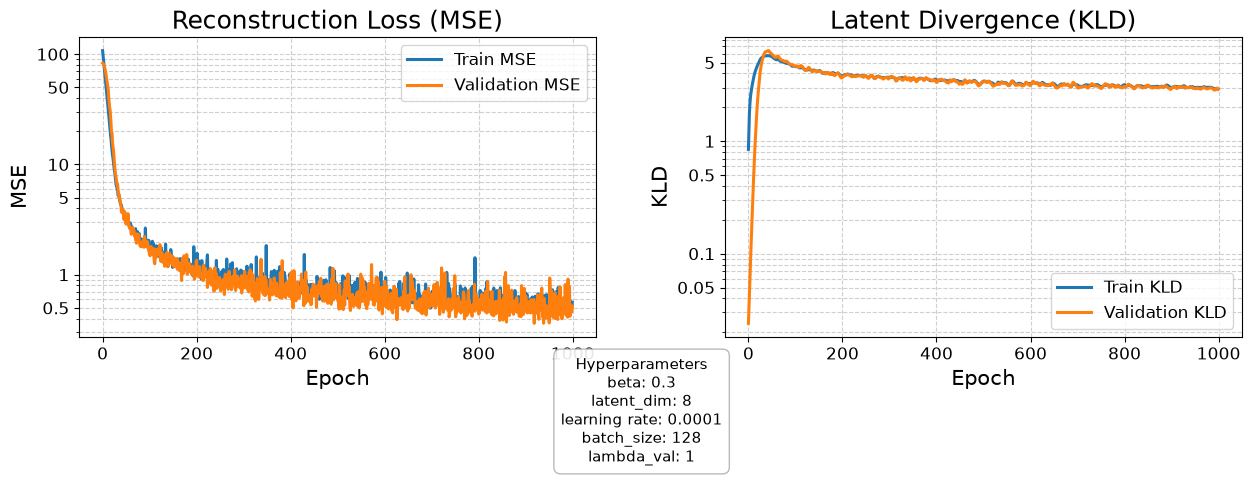

In [7]:
from src.utils import plot_loss_curve

plot_loss_curve(metrics)

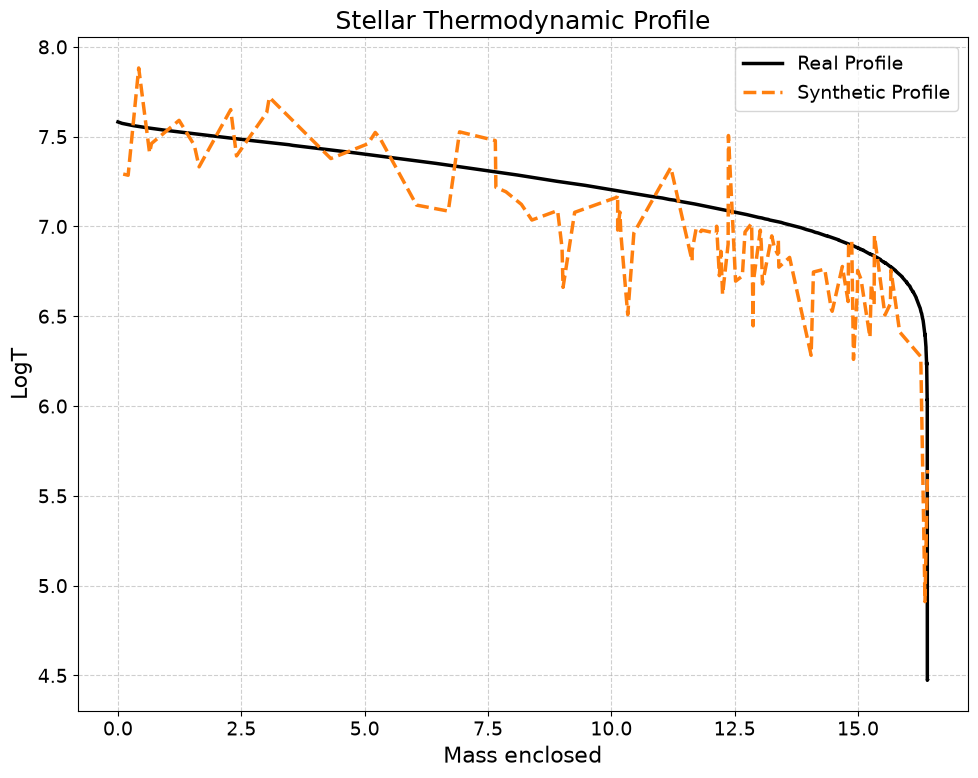

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from src.dataset import get_dataloaders
from src.config import profile_features, num_profile_points, model_save_dir
from src.model import VAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Model initialization and loading
model = VAE().to(device)
model_path = model_save_dir / "variational_autoencoder.pth" 
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 2. Data retrieval
_, val_loader, _ = get_dataloaders(condition_cols=[2])
real_profile = next(iter(val_loader))[0][0].numpy()

# Sort real profile to ensure sequential rendering
real_profile = real_profile[real_profile[:, 0].argsort()]

# 3. Scale real profile (wrapped in DataFrame to suppress sklearn warnings)
scaled_real_mass = scalers['mass'].transform(pd.DataFrame(real_profile[:, 0], columns=['mass']))
scaled_real_logT = scalers['logT'].transform(pd.DataFrame(real_profile[:, 1], columns=['logT']))
scaled_real_profile = np.hstack((scaled_real_mass, scaled_real_logT))

# 4. Forward pass
real_profile_flat = torch.from_numpy(scaled_real_profile).float().view(1, -1).to(device)
with torch.no_grad():
    reconstructed_flat, _, _ = model(real_profile_flat)

# 5. Reshape and inverse transform
synthetic_profile = reconstructed_flat.view(num_profile_points, len(profile_features)).cpu().numpy()

unscaled_mass = scalers['mass'].inverse_transform(pd.DataFrame(synthetic_profile[:, 0], columns=['mass']))
unscaled_logT = scalers['logT'].inverse_transform(pd.DataFrame(synthetic_profile[:, 1], columns=['logT']))

synthetic_profile[:, 0] = unscaled_mass.flatten()
synthetic_profile[:, 1] = unscaled_logT.flatten()

# Sort reconstructed synthetic profile strictly AFTER generation and scaling
synthetic_profile = synthetic_profile[synthetic_profile[:, 0].argsort()]

# 6. Plotting
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(real_profile[:, 0], real_profile[:, 1], label="Real Profile", color="black", linewidth=2.5)
ax.plot(synthetic_profile[:, 0], synthetic_profile[:, 1], label="Synthetic Profile", color="#ff7f0e", linestyle="--", linewidth=2.5)

ax.set_title("Stellar Thermodynamic Profile", fontsize=18)
ax.set_xlabel("Mass enclosed", fontsize=16) 
ax.set_ylabel("LogT", fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()